In [8]:
!pip install pandas numpy requests beautifulsoup4 lxml hmmlearn matplotlib scikit-learn

Start with 118th congress, 1st session

In [9]:
import pandas as pd
import glob
import os
import re

def load_vote_file(file_path):
    # Skip metadata + header, manually name columns
    df = pd.read_csv(
        file_path,
        skiprows=5,
        header=None,
        usecols=[0, 1, 2, 3],
        names=["Representative", "Party", "State", "Vote"]
    )

    # Clean text
    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    # Get roll call number from filename
    match = re.search(r"_(\d+)\.csv$", os.path.basename(file_path))
    if match:
        df["Roll_Call"] = int(match.group(1))
    else:
        df["Roll_Call"] = os.path.basename(file_path)

    vote_map = {
        "Yea": 1,
        "Nay": 0,
        "Present": 2,
        "Not Voting": 2
    }

    df["Vote_Code"] = df["Vote"].map(vote_map)

    return df


files = glob.glob("data/raw/votes_house_118_1_*.csv")

print("Files found:", len(files))
print(files[:5])

all_votes = pd.concat([load_vote_file(f) for f in files], ignore_index=True)

display(all_votes.head())
print(all_votes.shape)

Files found: 7
['data/raw/votes_house_118_1_719.csv', 'data/raw/votes_house_118_1_718.csv', 'data/raw/votes_house_118_1_724.csv', 'data/raw/votes_house_118_1_720.csv', 'data/raw/votes_house_118_1_721.csv']


,Representative,Party,State,Vote,Roll_Call,Vote_Code
0,"Adams, Alma S. [D-NC]",Democratic,North Carolina,Nay,719,0.0
1,"Aderholt, Robert B. [R-AL]",Republican,Alabama,Yea,719,1.0
2,"Aguilar, Pete [D-CA]",Democratic,California,Nay,719,0.0
3,"Alford, Mark [R-MO]",Republican,Missouri,Yea,719,1.0
4,"Allen, Rick W. [R-GA]",Republican,Georgia,Yea,719,1.0


(3035, 6)


CREATE THE HMM MATRIX

In [10]:
vote_matrix = all_votes.pivot_table(
    index="Representative",
    columns="Roll_Call",
    values="Vote_Code",
    aggfunc="first"
)

vote_matrix = vote_matrix.sort_index(axis=1)
vote_matrix = vote_matrix.fillna(2).astype(int)

display(vote_matrix.head())
print(vote_matrix.shape)

Roll_Call,718,719,720,721,722,723,724
Representative,,,,,,,
"Adams, Alma S. [D-NC]",0,0,2,0,0,1,1
"Aderholt, Robert B. [R-AL]",1,1,2,1,0,1,1
"Aguilar, Pete [D-CA]",0,0,2,0,0,1,1
"Alford, Mark [R-MO]",1,1,2,1,0,1,1
"Allen, Rick W. [R-GA]",1,1,2,1,0,1,1


(434, 7)


In [11]:
!pip install hmmlearn

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.metrics import accuracy_score

party labels created


In [14]:
rep_info = all_votes.groupby("Representative")[["Party", "State"]].first()

vote_matrix = vote_matrix.loc[rep_info.index]
vote_matrix = vote_matrix.fillna(2).astype(int)

display(vote_matrix.head())
display(rep_info.head())

Roll_Call,718,719,720,721,722,723,724
Representative,,,,,,,
"Adams, Alma S. [D-NC]",0,0,2,0,0,1,1
"Aderholt, Robert B. [R-AL]",1,1,2,1,0,1,1
"Aguilar, Pete [D-CA]",0,0,2,0,0,1,1
"Alford, Mark [R-MO]",1,1,2,1,0,1,1
"Allen, Rick W. [R-GA]",1,1,2,1,0,1,1


,Party,State
Representative,,
"Adams, Alma S. [D-NC]",Democratic,North Carolina
"Aderholt, Robert B. [R-AL]",Republican,Alabama
"Aguilar, Pete [D-CA]",Democratic,California
"Alford, Mark [R-MO]",Republican,Missouri
"Allen, Rick W. [R-GA]",Republican,Georgia


train hmm model now

In [15]:
n_states = 4

X = vote_matrix.values.reshape(-1, 1)
lengths = [vote_matrix.shape[1]] * vote_matrix.shape[0]

model = hmm.CategoricalHMM(
    n_components=n_states,
    n_features=3,
    n_iter=300,
    random_state=42,
    init_params="ste"
)

model.fit(X, lengths)

hidden_states = model.predict(X, lengths)

hidden_matrix = pd.DataFrame(
    hidden_states.reshape(vote_matrix.shape),
    index=vote_matrix.index,
    columns=vote_matrix.columns
)

display(hidden_matrix.head())

Roll_Call,718,719,720,721,722,723,724
Representative,,,,,,,
"Adams, Alma S. [D-NC]",1,3,0,2,2,2,2
"Aderholt, Robert B. [R-AL]",1,3,0,2,2,2,2
"Aguilar, Pete [D-CA]",1,3,0,2,2,2,2
"Alford, Mark [R-MO]",1,3,0,2,2,2,2
"Allen, Rick W. [R-GA]",1,3,0,2,2,2,2


heatmap generated

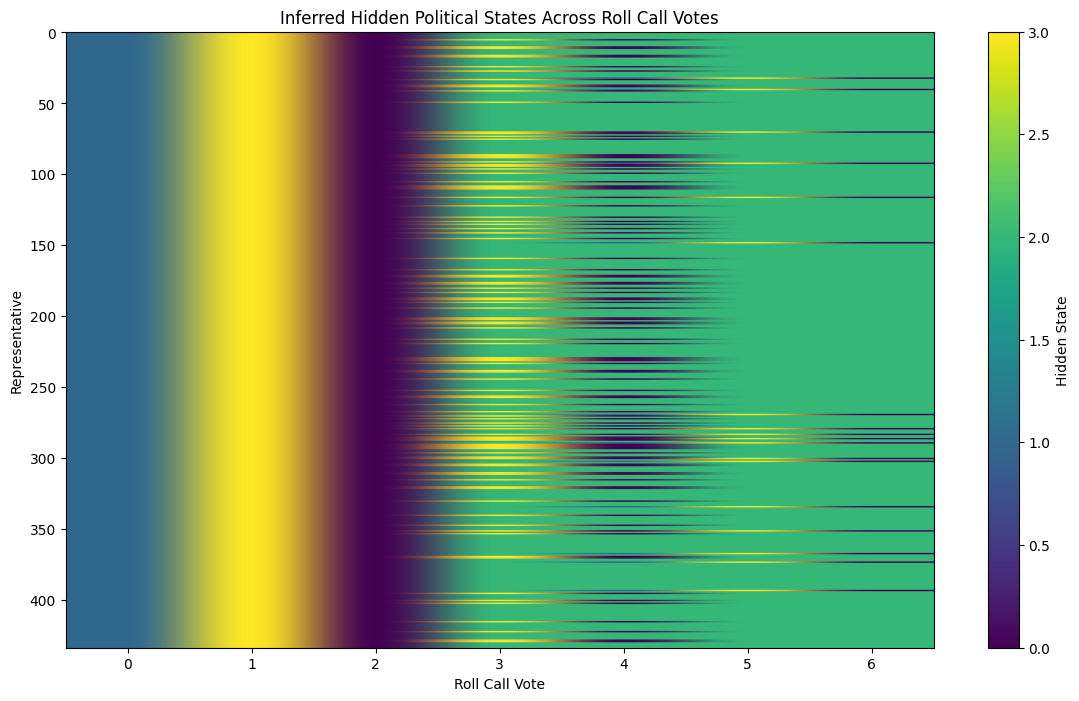

In [16]:
plt.figure(figsize=(14, 8))
plt.imshow(hidden_matrix.values, aspect="auto")
plt.colorbar(label="Hidden State")
plt.xlabel("Roll Call Vote")
plt.ylabel("Representative")
plt.title("Inferred Hidden Political States Across Roll Call Votes")
plt.show()

emission probabiltiies

,Nay,Yea,Present/Not Voting
0,1.015878e-26,1.084226e-65,1.000000
1,2.309332e-01,7.579391e-01,0.011128
2,3.579692e-01,6.366773e-01,0.005353
3,4.290227e-01,5.527768e-01,0.018200


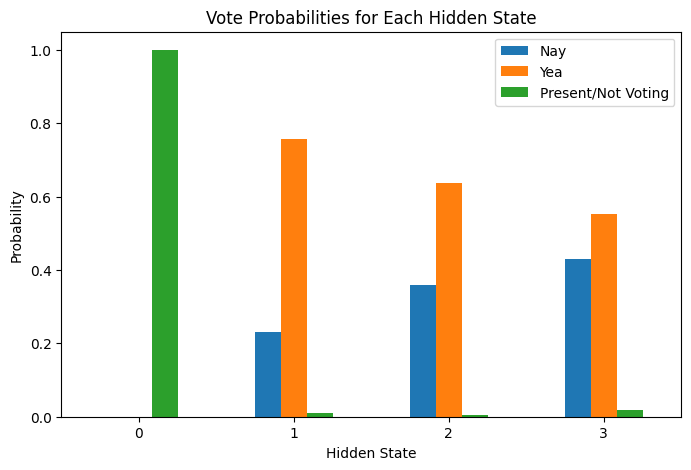

In [18]:
emissions = pd.DataFrame(
    model.emissionprob_,
    columns=["Nay", "Yea", "Present/Not Voting"]
)

display(emissions)

emissions.plot(kind="bar", figsize=(8,5))
plt.xlabel("Hidden State")
plt.ylabel("Probability")
plt.title("Vote Probabilities for Each Hidden State")
plt.xticks(rotation=0)
plt.show()

transition matrix

,0,1,2,3
0,1.230158e-23,1.771890e-49,7.978826e-01,2.021174e-01
1,2.022887e-271,5.141353e-232,3.099731e-97,1.000000e+00
2,9.026402e-05,2.910820e-02,9.708015e-01,4.314353e-33
3,1.000000e+00,1.141637e-131,8.062537e-144,1.336002e-177


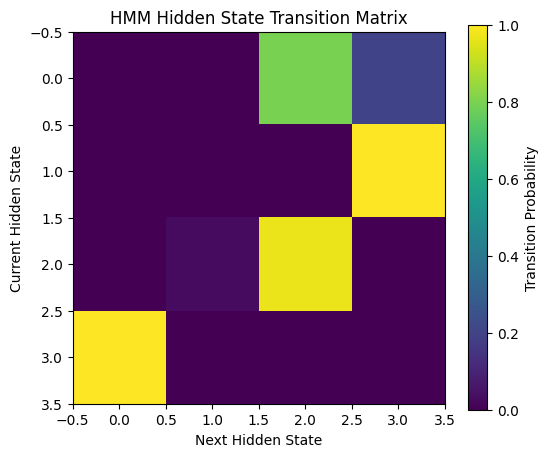

In [19]:
transitions = pd.DataFrame(model.transmat_)

display(transitions)

plt.figure(figsize=(6,5))
plt.imshow(model.transmat_)
plt.colorbar(label="Transition Probability")
plt.xlabel("Next Hidden State")
plt.ylabel("Current Hidden State")
plt.title("HMM Hidden State Transition Matrix")
plt.show()

compare diff numbers of hidden states

,Hidden States,Log Likelihood,Log Likelihood Per Vote
0,2,-2974.648728,-0.979147
1,3,-2393.728415,-0.787929
2,4,-1996.631591,-0.657219
3,5,-1706.258724,-0.561639
4,6,-1889.832475,-0.622065
5,8,-1472.507667,-0.484696
6,10,-1524.792600,-0.501907


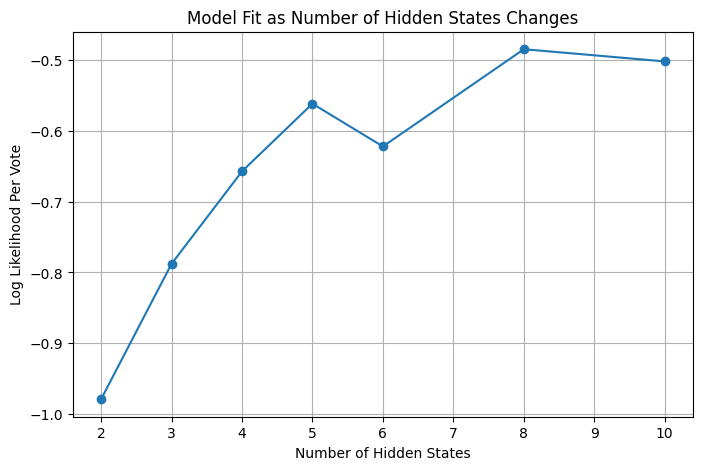

In [20]:
state_results = []

for k in [2, 3, 4, 5, 6, 8, 10]:
    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )
    
    temp_model.fit(X, lengths)
    log_likelihood = temp_model.score(X, lengths)
    
    state_results.append({
        "Hidden States": k,
        "Log Likelihood": log_likelihood,
        "Log Likelihood Per Vote": log_likelihood / len(X)
    })

state_results = pd.DataFrame(state_results)
display(state_results)

plt.figure(figsize=(8,5))
plt.plot(
    state_results["Hidden States"],
    state_results["Log Likelihood Per Vote"],
    marker="o"
)
plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood Per Vote")
plt.title("Model Fit as Number of Hidden States Changes")
plt.grid(True)
plt.show()

In [21]:
predicted_votes = []

for state in hidden_states:
    predicted_vote = np.argmax(model.emissionprob_[state])
    predicted_votes.append(predicted_vote)

actual_votes = X.flatten()
accuracy = accuracy_score(actual_votes, predicted_votes)

print("Vote reconstruction accuracy:", accuracy)

Vote reconstruction accuracy: 0.7073732718894009


,Hidden States,Accuracy
0,2,0.524358
1,3,0.708361
2,4,0.707373
3,5,0.781106
4,6,0.762673
5,8,0.883147
6,10,0.782752


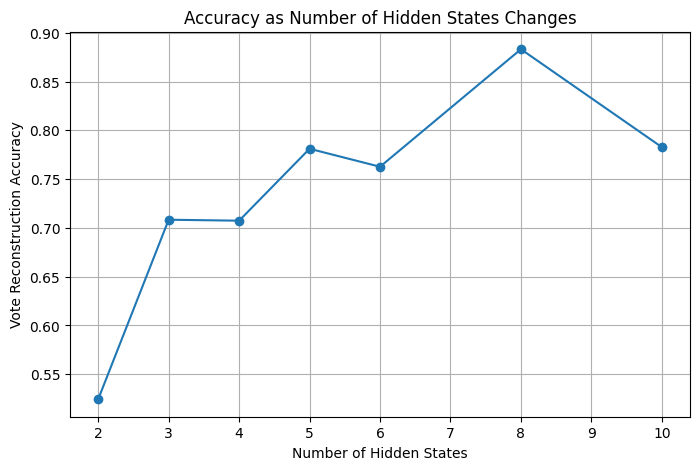

In [22]:
accuracy_results = []

for k in [2, 3, 4, 5, 6, 8, 10]:
    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )
    
    temp_model.fit(X, lengths)
    states = temp_model.predict(X, lengths)
    
    preds = [np.argmax(temp_model.emissionprob_[s]) for s in states]
    acc = accuracy_score(actual_votes, preds)
    
    accuracy_results.append({
        "Hidden States": k,
        "Accuracy": acc
    })

accuracy_results = pd.DataFrame(accuracy_results)
display(accuracy_results)

plt.figure(figsize=(8,5))
plt.plot(
    accuracy_results["Hidden States"],
    accuracy_results["Accuracy"],
    marker="o"
)
plt.xlabel("Number of Hidden States")
plt.ylabel("Vote Reconstruction Accuracy")
plt.title("Accuracy as Number of Hidden States Changes")
plt.grid(True)
plt.show()

Party,Democratic,Republican
Dominant Hidden State,,
0.0,47,68
2.0,166,153


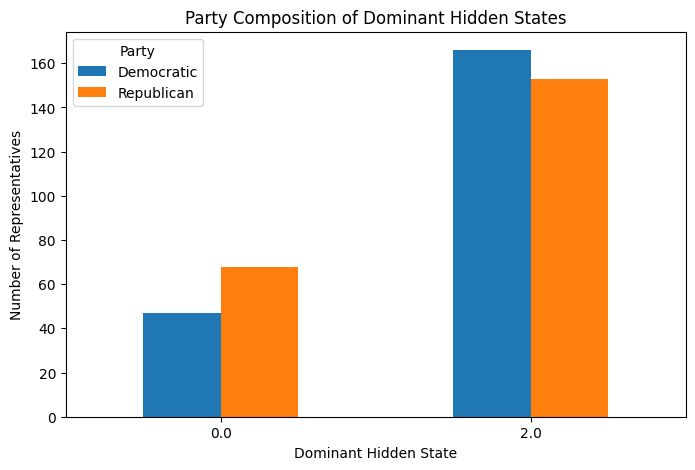

In [23]:
rep_dominant_state = hidden_matrix.mode(axis=1)[0]

party_state_df = pd.DataFrame({
    "Party": rep_info.loc[rep_dominant_state.index, "Party"],
    "Dominant Hidden State": rep_dominant_state
})

party_state_counts = pd.crosstab(
    party_state_df["Dominant Hidden State"],
    party_state_df["Party"]
)

display(party_state_counts)

party_state_counts.plot(kind="bar", figsize=(8,5))
plt.xlabel("Dominant Hidden State")
plt.ylabel("Number of Representatives")
plt.title("Party Composition of Dominant Hidden States")
plt.xticks(rotation=0)
plt.show()

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

EXPIERIMENT TABLE

In [26]:
results = []

actual_votes = X.flatten()

for k in [2, 3, 4, 5, 6, 8, 10]:

    temp_model = hmm.CategoricalHMM(
        n_components=k,
        n_features=3,
        n_iter=300,
        random_state=42,
        init_params="ste"
    )

    temp_model.fit(X, lengths)

    hidden_states = temp_model.predict(X, lengths)

    predicted_votes = []

    for state in hidden_states:
        pred_vote = np.argmax(temp_model.emissionprob_[state])
        predicted_votes.append(pred_vote)

    accuracy = accuracy_score(actual_votes, predicted_votes)

    precision = precision_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        actual_votes,
        predicted_votes,
        average="weighted",
        zero_division=0
    )

    log_likelihood = temp_model.score(X, lengths)

    results.append({
        "Hidden States": k,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Log Likelihood Per Vote":
            log_likelihood / len(X)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Hidden States,Accuracy,Precision,Recall,F1 Score,Log Likelihood Per Vote
0,2,0.524358,0.274951,0.524358,0.360744,-0.979147
1,3,0.708361,0.507723,0.708361,0.590912,-0.787929
2,4,0.707373,0.525484,0.707373,0.595895,-0.657219
3,5,0.781106,0.794412,0.781106,0.756666,-0.561639
4,6,0.762673,0.832058,0.762673,0.706301,-0.622065
5,8,0.883147,0.887677,0.883147,0.879429,-0.484696
6,10,0.782752,0.799376,0.782752,0.758201,-0.501907


ACCURACY/F1 GRAPH

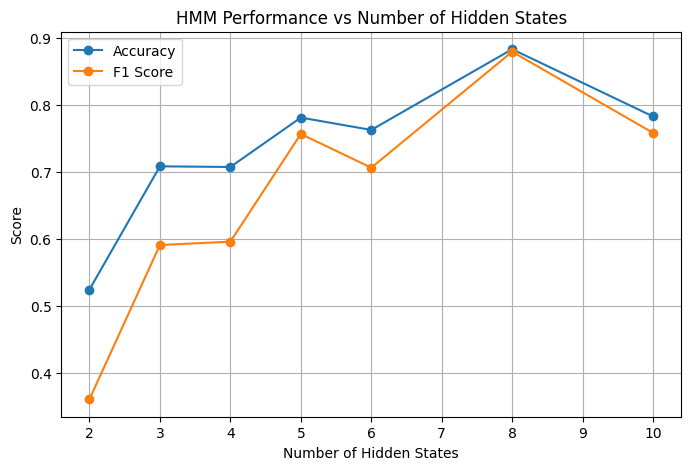

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Hidden States"],
    results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results_df["Hidden States"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Score")
plt.title("HMM Performance vs Number of Hidden States")
plt.legend()
plt.grid(True)

plt.show()

LOG LIKELIHOOD GRAPH

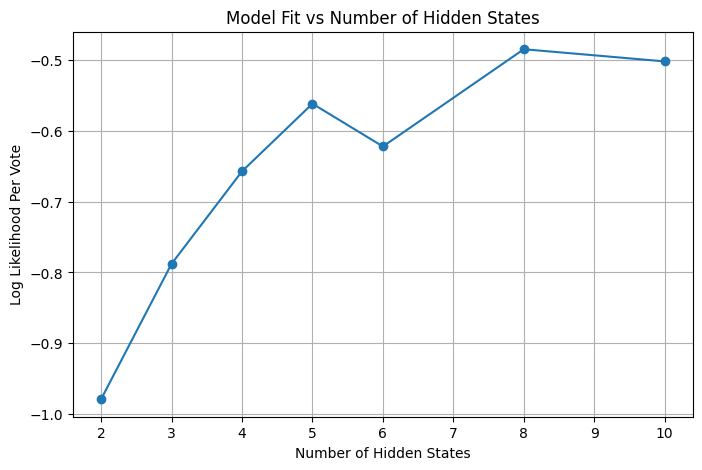

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Hidden States"],
    results_df["Log Likelihood Per Vote"],
    marker="o"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood Per Vote")

plt.title("Model Fit vs Number of Hidden States")

plt.grid(True)

plt.show()